In [2]:
import pandas as pd

ident = pd.read_csv('C:/Users/INDIA/Documents/FraudDetectionPlatform/data/raw/train_identity.csv')
trans = pd.read_csv('C:/Users/INDIA/Documents/FraudDetectionPlatform/data/raw/train_transaction.csv')

df = trans.merge(ident, on = 'TransactionID', how='left')

In [2]:
print(df.shape)

(590540, 434)


In [5]:
fraud_rate = df['isFraud'].value_counts(sum)
print(fraud_rate)

isFraud
0    0.96501
1    0.03499
Name: proportion, dtype: float64


In [6]:
missing = df.isnull().mean().sort_values(ascending=False)
print(missing[missing>0.5])

id_24    0.991962
id_25    0.991310
id_07    0.991271
id_08    0.991271
id_21    0.991264
           ...   
M5       0.593494
M7       0.586353
M9       0.586331
M8       0.586331
D5       0.524674
Length: 214, dtype: float64


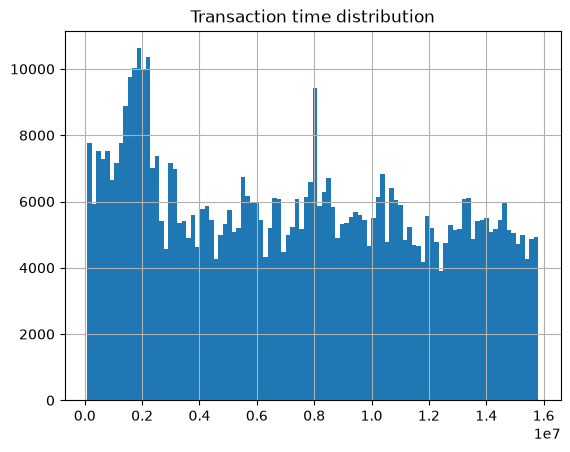

count    5.905400e+05
mean     7.372311e+06
std      4.617224e+06
min      8.640000e+04
25%      3.027058e+06
50%      7.306528e+06
75%      1.124662e+07
max      1.581113e+07
Name: TransactionDT, dtype: float64


In [ ]:
import matplotlib.pyplot as plt

df['TransactionDT'].hist(bins=100)
plt.title('Transaction time distribution')
plt.show()

print(df['TransactionDT'].describe())

C:\Users\INDIA\AppData\Local\Temp\ipykernel_3784\2547486312.py:1: PerformanceWarning: DataFrame is highly fragmented.  This is usually the result of calling `frame.insert` many times, which has poor performance.  Consider joining all columns at once using pd.concat(axis=1) instead. To get a de-fragmented frame, use `newframe = frame.copy()`
  df['time_bin'] = pd.cut(df['TransactionDT'], bins = 20)


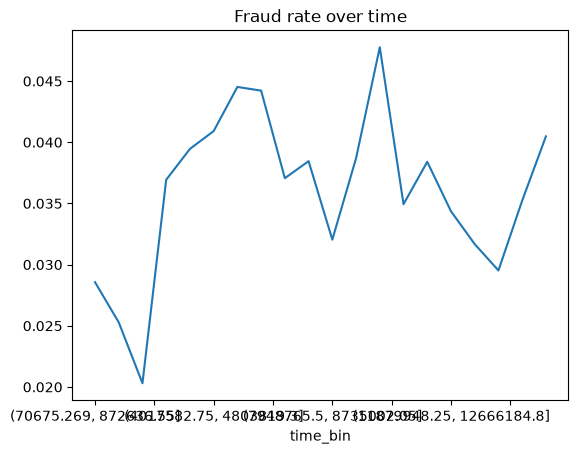

In [4]:
df['time_bin'] = pd.cut(df['TransactionDT'], bins = 20)
fraud_over_time = df.groupby('time_bin')['isFraud'].mean()

fraud_over_time.plot()
plt.title('Fraud rate over time')
plt.show()

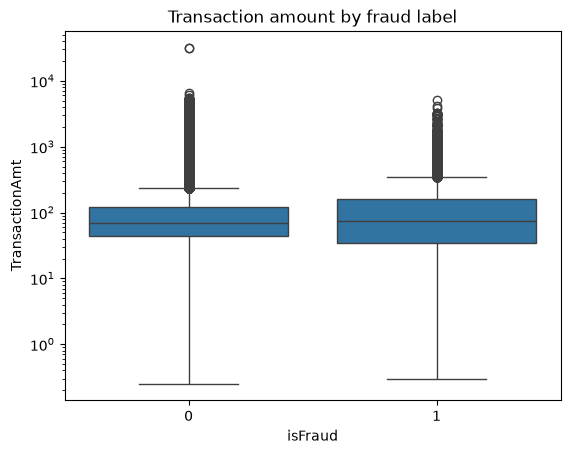

In [ ]:
import seaborn as sns

sns.boxplot(x='isFraud', y ='TransactionAmt', data=df)
plt.yscale('log')

plt.title('Transaction amount by fraud label')

plt.show()

In [6]:
import sys
sys.path.append('../')

from src.data.features import engineer_features

df_featured = engineer_features(df)

# Sanity checks
print("New columns added:", 
      [c for c in df_featured.columns if c not in df.columns])
print("tx_hour range:", df_featured['tx_hour'].min(), 
      "–", df_featured['tx_hour'].max())
print("amt_deviation sample:", 
      df_featured['amt_deviation'].describe())
print("Any NaNs left:", df_featured.isnull().sum().sum())

New columns added: ['tx_hour', 'tx_day', 'tx_hour_sin', 'tx_hour_cos', 'id_01_was_missing', 'id_02_was_missing', 'id_03_was_missing', 'id_04_was_missing', 'id_05_was_missing', 'id_06_was_missing', 'id_07_was_missing', 'id_08_was_missing', 'id_09_was_missing', 'id_10_was_missing', 'id_11_was_missing', 'DeviceType_was_missing', 'DeviceInfo_was_missing', 'card1_freq', 'card2_freq', 'card4_freq', 'card6_freq', 'P_emaildomain_freq', 'R_emaildomain_freq', 'DeviceInfo_freq', 'id_30_freq', 'id_31_freq', 'card1_count_1h', 'card1_mean_amt_1h', 'card1_count_24h', 'card1_mean_amt_24h', 'amt_deviation']
tx_hour range: 0.0 – 23.0
amt_deviation sample: count    590540.000000
mean          5.076532
std         229.623936
min       -4019.970000
25%         -71.726215
50%         -31.049286
75%          13.288677
max       31718.559014
Name: amt_deviation, dtype: float64
Any NaNs left: 0
